# 05 - Kiểm thử Module Visualization
Kiểm tra việc vẽ đồ thị 2 tầng (Dạng sóng + STE/Ngưỡng) và xuất file hình ảnh kiểm thử.


In [4]:
import sys
from pathlib import Path
from IPython.display import Image, display

ROOT_DIR = Path.cwd().resolve()
while ROOT_DIR.name != 'main_gk' and ROOT_DIR.parent != ROOT_DIR:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.audio.dataset import load_dataset
from src.segmentation.threshold import calibrate_thresholds
from src.segmentation.segment import segment_signal
from src.evaluate.metrics import evaluate_signal
from src.visualization.plotting import plot_signal_segmentation, visualize_test_dataset


### 1. Vẽ trực quan hóa cho một file kiểm thử đơn lẻ


  [Đã lưu hình]: /home/phuqy/Documents/main_gk/reports/figures/demo_test_studio_F2.png


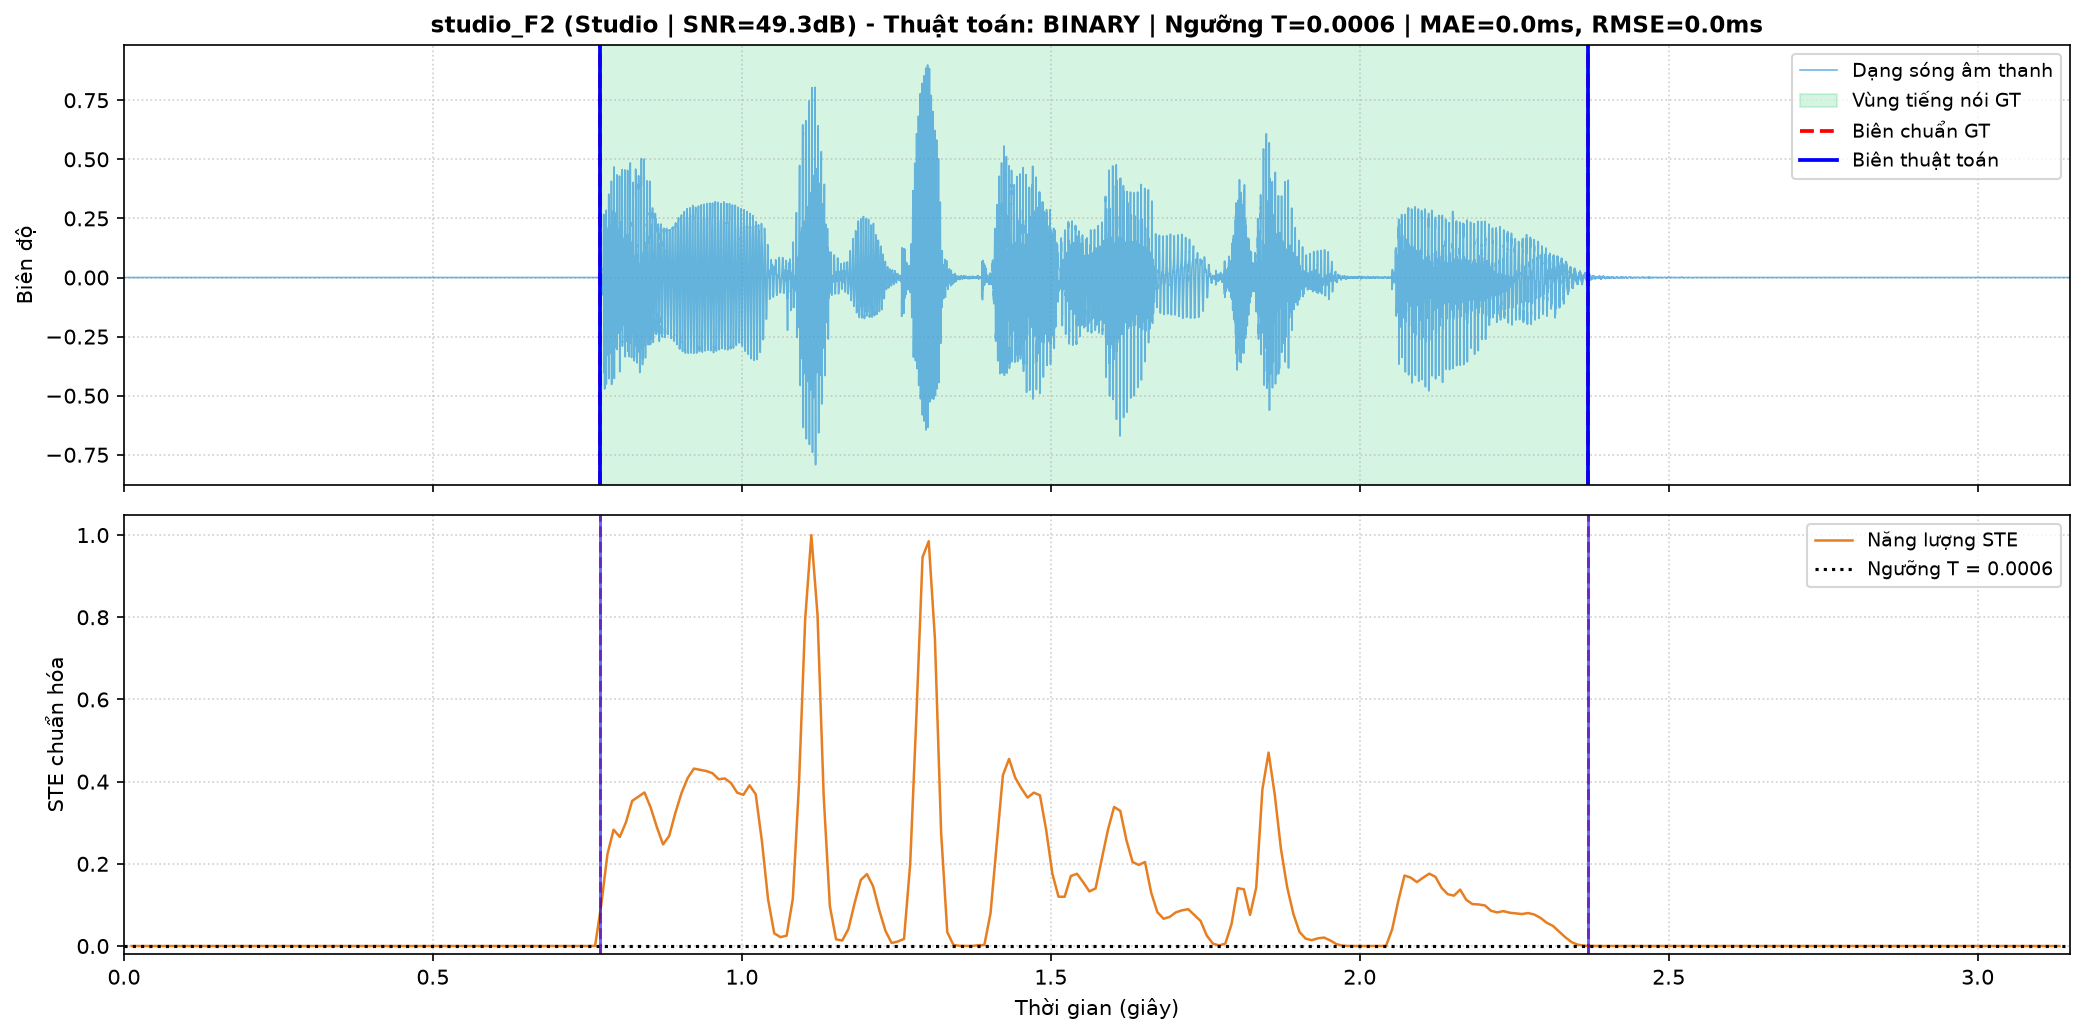

In [5]:
train_signals = load_dataset(ROOT_DIR / 'TinHieuHuanLuyen')
test_signals = load_dataset(ROOT_DIR / 'TinHieuKiemThu')
thresholds = calibrate_thresholds(train_signals)

sig = test_signals[2]  # studio_F2
th = thresholds.get_threshold('binary', sig.is_phone)
res = segment_signal(sig, th, algorithm='binary', min_silence_ms=200.0)
met = evaluate_signal(sig, res.predicted_boundaries, algorithm='binary', threshold=th)

fig_path = ROOT_DIR / 'reports' / 'figures' / 'demo_test_studio_F2.png'
fig = plot_signal_segmentation(sig, res, met, save_path=fig_path, show=False)

# Hiển thị ảnh trực tiếp trong Notebook
display(Image(filename=str(fig_path)))


### 2. Xuất toàn bộ 4 figure cho tập kiểm thử (đúng yêu cầu đề bài)


In [6]:
results = []
metrics_list = []
for s in test_signals:
    th = thresholds.get_threshold('binary', s.is_phone)
    r = segment_signal(s, th, algorithm='binary', min_silence_ms=200.0)
    m = evaluate_signal(s, r.predicted_boundaries, algorithm='binary', threshold=th)
    results.append(r)
    metrics_list.append(m)

saved = visualize_test_dataset(test_signals, results, metrics_list, output_dir=ROOT_DIR / 'reports' / 'figures')
print(f'Đã tạo thành công {len(saved)} ảnh kiểm thử.')


  [Đã lưu hình]: /home/phuqy/Documents/main_gk/reports/figures/figure_1_phone_F2_binary.png
  [Đã lưu hình]: /home/phuqy/Documents/main_gk/reports/figures/figure_2_phone_M2_binary.png
  [Đã lưu hình]: /home/phuqy/Documents/main_gk/reports/figures/figure_3_studio_F2_binary.png
  [Đã lưu hình]: /home/phuqy/Documents/main_gk/reports/figures/figure_4_studio_M2_binary.png
Đã tạo thành công 4 ảnh kiểm thử.
